In [2]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import sklearn
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

2026-05-16 19:39:36.432786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778960376.456191    1239 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778960376.463955    1239 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778960376.485060    1239 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778960376.485084    1239 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778960376.485086    1239 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/datasets/ziadhafez/mentalhealth/Combined Data.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(53043, 3)
['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
print(df.describe())

         Unnamed: 0
count  53043.000000
mean   26521.000000
std    15312.339501
min        0.000000
25%    13260.500000
50%    26521.000000
75%    39781.500000
max    53042.000000


In [5]:
df = df.drop(columns=['Unnamed: 0'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     53043 non-null  object
dtypes: object(2)
memory usage: 828.9+ KB


In [7]:
df = df.dropna(subset=['statement'])
df = df.dropna(subset=['status'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     52681 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51093 entries, 0 to 52840
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  51093 non-null  object
 1   status     51093 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [11]:
print(df['status'].value_counts())

status
Normal                  16040
Depression              15094
Suicidal                10644
Anxiety                  3623
Bipolar                  2501
Stress                   2296
Personality disorder      895
Name: count, dtype: int64


In [12]:
print(df['status'].value_counts(normalize=True) * 100)

status
Normal                  31.393733
Depression              29.542207
Suicidal                20.832599
Anxiety                  7.090991
Bipolar                  4.894995
Stress                   4.493766
Personality disorder     1.751708
Name: proportion, dtype: float64


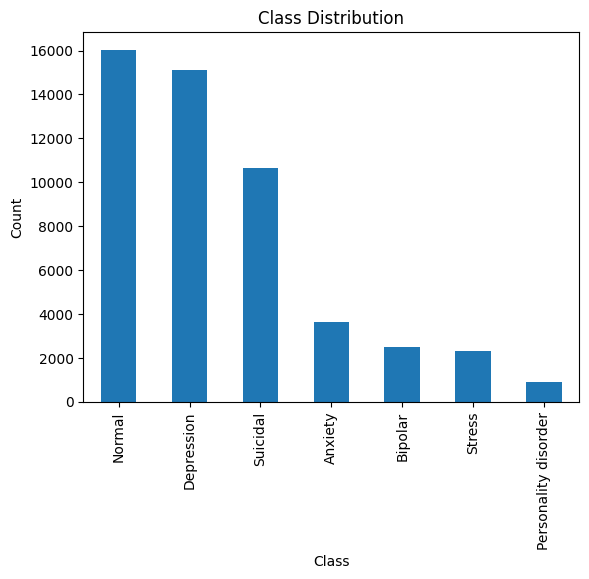

In [13]:
import matplotlib.pyplot as plt

df['status'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [14]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

In [15]:
df.head()

,statement,status
0,oh my gosh,0
1,"trouble sleeping, confused mind, restless hear...",0
2,"All wrong, back off dear, forward doubt. Stay ...",0
3,I've shifted my focus to something else but I'...,0
4,"I'm restless and restless, it's been a month n...",0


In [1]:
!pip install transformers -q

import torch
import numpy as np
import pickle
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [16]:
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            list(texts),
            max_length=max_length,
            truncation=True,
            padding=True,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

In [17]:
bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Use raw text, no need for clean_text or lemmatize
X_train, X_test, y_train, y_test = train_test_split(
    df['statement'].values,
    df['status'].values,
    test_size=0.2,
    random_state=42
)

train_dataset = MentalHealthDataset(X_train, y_train, bert_tokenizer)
test_dataset  = MentalHealthDataset(X_test,  y_test,  bert_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

In [18]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

num_classes = 7

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_classes
)
model.to(device)
class_weights_tensor = class_weights_tensor.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 3
EPOCHS = 10

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_train_loss = 0
    total_train_correct = 0

    for i, batch in enumerate(train_loader):  # ← add enumerate here
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        torch.cuda.empty_cache()

        total_train_loss += loss.item()
        total_train_correct += (outputs.logits.argmax(dim=1) == labels).sum().item()

        if (i + 1) % 100 == 0:  # ← now i is defined
            print(f"  Epoch {epoch+1} | Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_acc  = total_train_correct / len(train_dataset)
    train_loss = total_train_loss / len(train_loader)

    # --- Validate ---
    model.eval()
    total_val_loss = 0
    total_val_correct = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)

            total_val_loss += loss.item()
            total_val_correct += (outputs.logits.argmax(dim=1) == labels).sum().item()

    val_acc  = total_val_correct / len(test_dataset)
    val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} — Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

model.load_state_dict(torch.load('best_model.pt'))

  Epoch 1 | Batch 100/1278 | Loss: 0.5359
  Epoch 1 | Batch 200/1278 | Loss: 0.6330
  Epoch 1 | Batch 300/1278 | Loss: 0.3873
  Epoch 1 | Batch 400/1278 | Loss: 0.2500
  Epoch 1 | Batch 500/1278 | Loss: 0.4787
  Epoch 1 | Batch 600/1278 | Loss: 0.6327
  Epoch 1 | Batch 700/1278 | Loss: 0.4043
  Epoch 1 | Batch 800/1278 | Loss: 1.4506
  Epoch 1 | Batch 900/1278 | Loss: 0.3975
  Epoch 1 | Batch 1000/1278 | Loss: 0.4308
  Epoch 1 | Batch 1100/1278 | Loss: 0.2838
  Epoch 1 | Batch 1200/1278 | Loss: 0.9643
Epoch 1/10 — Train Loss: 0.5974 | Train Acc: 0.7754 | Val Loss: 0.5323 | Val Acc: 0.7887
  Epoch 2 | Batch 100/1278 | Loss: 0.1681
  Epoch 2 | Batch 200/1278 | Loss: 0.3138
  Epoch 2 | Batch 300/1278 | Loss: 0.8815
  Epoch 2 | Batch 400/1278 | Loss: 0.7272
  Epoch 2 | Batch 500/1278 | Loss: 1.2047
  Epoch 2 | Batch 600/1278 | Loss: 0.6048
  Epoch 2 | Batch 700/1278 | Loss: 0.2848
  Epoch 2 | Batch 800/1278 | Loss: 0.2198
  Epoch 2 | Batch 900/1278 | Loss: 0.3900
  Epoch 2 | Batch 1000/127

<All keys matched successfully>

In [22]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=le.classes_))

                      precision    recall  f1-score   support

             Anxiety       0.85      0.90      0.87       727
             Bipolar       0.87      0.84      0.86       518
          Depression       0.83      0.68      0.75      2950
              Normal       0.97      0.90      0.93      3271
Personality disorder       0.55      0.75      0.64       179
              Stress       0.54      0.86      0.67       465
            Suicidal       0.68      0.81      0.74      2109

            accuracy                           0.81     10219
           macro avg       0.76      0.82      0.78     10219
        weighted avg       0.83      0.81      0.81     10219



In [23]:
import pickle

model.save_pretrained('/kaggle/working/mental_health_model')
bert_tokenizer.save_pretrained('/kaggle/working/bert_tokenizer')

with open('/kaggle/working/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved successfully!
